# Alignment Data Analysis

## Setup and imports


In [83]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))


In [84]:
from brighteyes_flim import mcs
from brighteyes_flim import Alignment


## Analysis parameters


In [85]:
CHANNEL = 12
C_REF = 1.0
IRF_ITERATIONS = 300
FIT_MODE = "irf_shift" #"model_shift" 

## Helper functions


In [86]:



def extract_channel_hist(data_6d, channel=CHANNEL):
    return np.asarray(data_6d[0, 0, :, :, :, channel].sum(axis=(0, 1)), dtype=float)


def build_time_axis(metadata):
    nbin = int(metadata.dfd_nbins)
    period_ns = 1 / (metadata.dfd_freq * 1e6) * 1e9
    dt_ns = period_ns / nbin
    t_ns = np.arange(nbin) * dt_ns
    return nbin, dt_ns, period_ns, t_ns


## Load reference and data histograms


In [87]:
f_ref = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/FLIMLABS_Yellow_slide_2_5ns-17-03-2026-16-18-22.h5"
tau_ref_ns = 2.5

f_data = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/01_Convallaria_DFD_40MHz-17-03-2026-16-59-41.h5"

ref_data_6d, metadata_ref = mcs.load(f_ref)
data_6d, metadata_data = mcs.load(f_data)

ref_hist_raw = extract_channel_hist(ref_data_6d)
data_hist_raw = extract_channel_hist(data_6d)

nbin, dt_ns, period_ns, t_ns = build_time_axis(metadata_data)

data_hist_raw_norm = data_hist_raw / data_hist_raw.sum()
ref_hist_raw_norm = ref_hist_raw / ref_hist_raw.sum()


## Estimate the IRF from the reference measurement


In [88]:
est_irf_ref = np.asarray(
    Alignment.IRF_from_data_deconvolution(
        ref_hist_raw_norm,
        t_ns,
        C_REF,
        tau_ref_ns,
        period_ns,
        iterations=IRF_ITERATIONS,
        regularization=0
    ),
    dtype=float,
)
est_irf_ref_norm = est_irf_ref / est_irf_ref.sum()

setup_df = pd.DataFrame(
    [
        {
            "channel": CHANNEL,
            "nbin": nbin,
            "dt_ns": dt_ns,
            "period_ns": period_ns,
            "tau_ref_ns": tau_ref_ns,
            "reference_counts": ref_hist_raw.sum(),
            "data_counts": data_hist_raw.sum(),
        }
    ]
)

display(setup_df.round(6))


,channel,nbin,dt_ns,period_ns,tau_ref_ns,reference_counts,data_counts
0,12,91,0.274725,25.0,2.5,245964.0,3921794.0


## Baseline fit of the data using the estimated IRF


Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}


,C,dT_bins,dT_ns,tau_ns
0,7.653533,-5.009007,-1.376101,1.434249


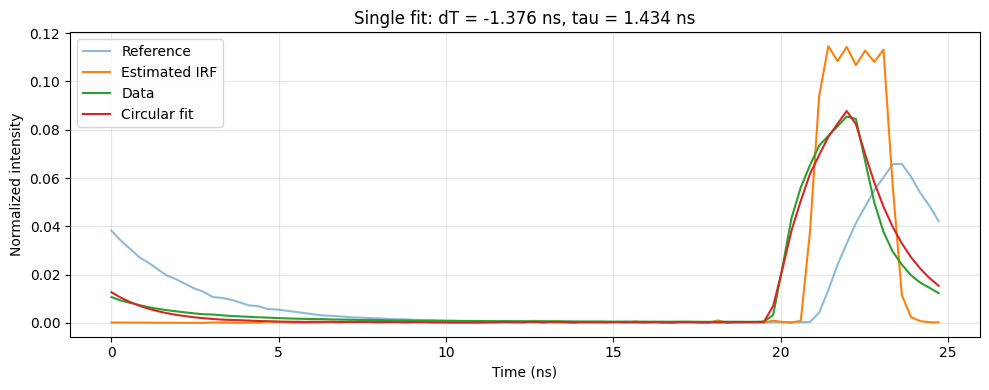

In [89]:
fit_result, fit_cov = Alignment.perform_fit_data(
    t_ns,
    data_hist_raw,
    est_irf_ref,
    period_ns,
    fit_type="circular",
    mode=FIT_MODE
)

fitted_hist = np.asarray(
    Alignment.fit_model_data(
        t_ns,
        fit_result["C"],
        fit_result["dT"],
        fit_result["tau"],
        irf=est_irf_ref_norm,
        period=period_ns,
    ),
    dtype=float,
)

single_fit_df = pd.DataFrame(
    [
        {
            "C": float(fit_result["C"]),
            "dT_bins": float(fit_result["dT"]),
            "dT_ns": float(fit_result["dT"] * dt_ns),
            "tau_ns": float(fit_result["tau"]),
        }
    ]
)

display(single_fit_df.round(6))

plt.figure(figsize=(10, 4))
plt.plot(t_ns, ref_hist_raw_norm, label="Reference", alpha=0.5)
plt.plot(t_ns, est_irf_ref_norm, label="Estimated IRF")
plt.plot(t_ns, data_hist_raw_norm, label="Data")
plt.plot(t_ns, fitted_hist / fitted_hist.sum(), label="Circular fit")
plt.xlabel("Time (ns)")
plt.ylabel("Normalized intensity")
plt.title(f"Single fit: dT = {fit_result['dT'] * dt_ns:.3f} ns, tau = {fit_result['tau']:.3f} ns")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Verify the robustness of the fit by shifting the reference with np.roll

Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.7252747

,shift,shift_ns,C,dT_bins,dT_ns,phasor_dT_bins,phasor_dT_ns,tau_ns,irf_peak_bin
0,0,0.000000,7.653533,-5.009007,-1.376101,0.481544,0.132292,1.434249,78
1,1,0.274725,0.727499,-4.009007,-1.101375,1.481544,0.407018,1.434249,77
2,2,0.549451,5.783014,-3.009006,-0.826650,2.481544,0.681743,1.434249,76
3,3,0.824176,2.854739,-2.009006,-0.551925,3.481544,0.956468,1.434249,75
4,4,1.098901,3.033416,-1.009007,-0.277200,4.481544,1.231193,1.434249,74
5,5,1.373626,1.298069,-0.009006,-0.002474,5.481544,1.505919,1.434249,73
6,6,1.648352,0.965523,0.990993,0.272251,6.481544,1.780644,1.434249,72
7,7,1.923077,0.482031,1.990994,0.546976,7.481544,2.055369,1.434249,71
8,8,2.197802,0.001967,2.990993,0.821701,8.481544,2.330094,1.434249,70
9,9,2.472527,5.944189,3.990993,1.096427,9.481544,2.604820,1.434249,69


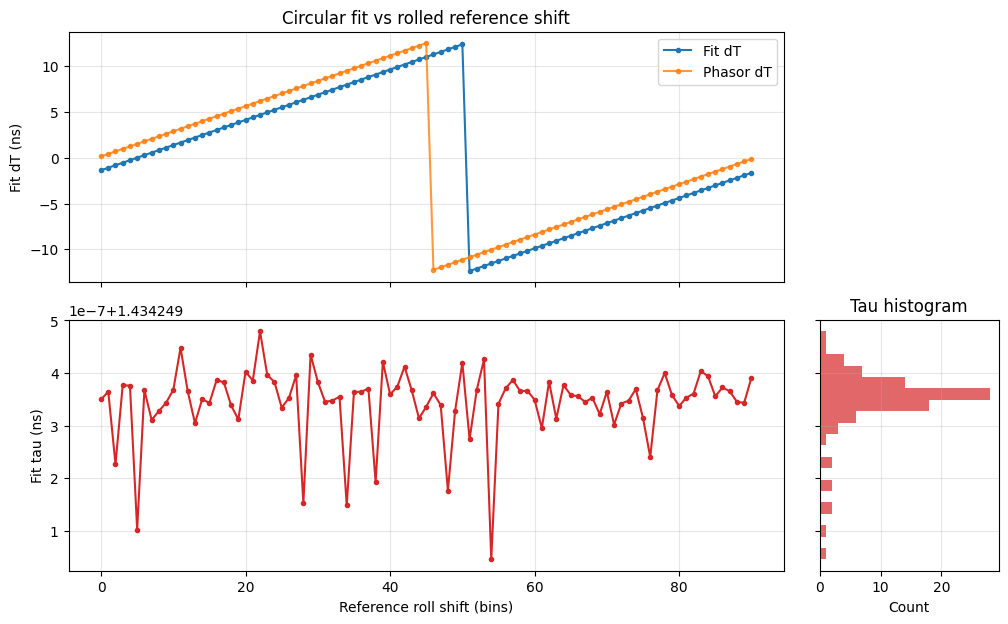

In [90]:
shift_values = np.arange(nbin)
scan_rows = []

_, _, data_phasor_delay_ns = Alignment.phasor_delay_from_hist(data_hist_raw, period_ns)

for shift in shift_values:
    ref_hist_shifted = np.roll(ref_hist_raw, -shift)
    ref_hist_shifted_norm = ref_hist_shifted / ref_hist_shifted.sum()

    est_irf_shifted = np.asarray(
        Alignment.IRF_from_data_deconvolution(
            ref_hist_shifted_norm,
            t_ns,
            C_REF,
            tau_ref_ns,
            period_ns,
            iterations=IRF_ITERATIONS,
            regularization=0
        ),
        dtype=float,
    )
    est_irf_shifted_norm = est_irf_shifted / est_irf_shifted.sum()

    fit_result_shifted, fit_cov_shifted = Alignment.perform_fit_data(
        t_ns,
        data_hist_raw,
        est_irf_shifted,
        period_ns,
        fit_type="circular",
        mode=FIT_MODE
    )

    _, _, irf_phasor_delay_ns = Alignment.phasor_delay_from_hist(est_irf_shifted, period_ns)
    phasor_dT_ns = ((data_phasor_delay_ns - irf_phasor_delay_ns + period_ns / 2) % period_ns) - period_ns / 2

    scan_rows.append(
        {
            "shift": int(shift),
            "shift_ns": float(shift * dt_ns),
            "C": float(fit_result_shifted["C"]),
            "dT_bins": float(fit_result_shifted["dT"]),
            "dT_ns": float(fit_result_shifted["dT"] * dt_ns),
            "phasor_dT_bins": float(phasor_dT_ns / dt_ns),
            "phasor_dT_ns": float(phasor_dT_ns),
            "tau_ns": float(fit_result_shifted["tau"]),
            "irf_peak_bin": int(np.argmax(est_irf_shifted_norm)),
        }
    )

scan_results_df = pd.DataFrame(scan_rows)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(scan_results_df.round(6))

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], hspace=0.15, wspace=0.08)
ax_dt = fig.add_subplot(gs[0, 0])
ax_tau = fig.add_subplot(gs[1, 0], sharex=ax_dt)
ax_tau_hist = fig.add_subplot(gs[1, 1], sharey=ax_tau)

ax_dt.plot(scan_results_df["shift"], scan_results_df["dT_ns"], color="tab:blue", marker=".", label="Fit dT")
ax_dt.plot(scan_results_df["shift"], scan_results_df["phasor_dT_ns"], color="tab:orange", marker=".", alpha=0.8, label="Phasor dT")
ax_dt.set_ylabel("Fit dT (ns)")
ax_dt.set_title("Circular fit vs rolled reference shift")
ax_dt.grid(True, alpha=0.3)
ax_dt.legend()
ax_dt.tick_params(labelbottom=False)

ax_tau.plot(scan_results_df["shift"], scan_results_df["tau_ns"], color="tab:red", marker=".")
ax_tau.set_xlabel("Reference roll shift (bins)")
ax_tau.set_ylabel("Fit tau (ns)")
ax_tau.grid(True, alpha=0.3)

ax_tau_hist.hist(scan_results_df["tau_ns"], bins=20, orientation="horizontal", color="tab:red", alpha=0.7)
ax_tau_hist.set_xlabel("Count")
ax_tau_hist.set_title("Tau histogram")
ax_tau_hist.grid(True, alpha=0.3)
ax_tau_hist.tick_params(labelleft=False)

plt.show()


## Interactive exploration of the shifted reference


In [91]:
from ipywidgets import interact, IntSlider, Checkbox

@interact(
    shift=IntSlider(value=0, min=0, max=nbin-1, step=1, description='Ref shift'),
    show_ref_irf=Checkbox(value=True, description='Show ref IRF'),
)
def interactive_fit(shift, show_ref_irf):
    ref_hist_shifted = np.roll(ref_hist_raw, -shift)
    ref_hist_shifted_norm = ref_hist_shifted / ref_hist_shifted.sum()

    est_irf_shifted = np.asarray(
        Alignment.IRF_from_data_deconvolution(
            ref_hist_shifted_norm,
            t_ns,
            C_REF,
            tau_ref_ns,
            period_ns,
            iterations=IRF_ITERATIONS,
            regularization=0
        ),
        dtype=float,
    )
    est_irf_shifted_norm = est_irf_shifted / est_irf_shifted.sum()

    fit_result_shifted, fit_cov_shifted = Alignment.perform_fit_data(
        t_ns,
        data_hist_raw,
        est_irf_shifted,
        period_ns,
        fit_type="circular",
        mode=FIT_MODE
    )

    fitted_hist_shifted = np.asarray(
        Alignment.fit_model_data(
            t_ns,
            fit_result_shifted["C"],
            fit_result_shifted["dT"],
            fit_result_shifted["tau"],
            irf=est_irf_shifted_norm,
            period=period_ns,
        ),
        dtype=float,
    )
    fitted_hist_shifted_norm = fitted_hist_shifted / fitted_hist_shifted.sum()

    plt.figure(figsize=(10, 4))
    plt.plot(t_ns, data_hist_raw_norm, label="Data", color="tab:blue")
    plt.plot(t_ns, ref_hist_raw_norm, label="Reference histogram (original)", color="tab:purple", alpha=0.4)
    plt.plot(t_ns, ref_hist_shifted_norm, label="Reference histogram (shifted)", color="tab:purple", alpha=0.8)
    plt.plot(t_ns, fitted_hist_shifted_norm, label="Fit (from shifted reference)", color="tab:orange")
    if show_ref_irf:
        plt.plot(t_ns, est_irf_shifted_norm, label="Estimated IRF (shifted reference)", color="tab:green", alpha=0.8)
    plt.xlabel("Time (ns)")
    plt.ylabel("Normalized intensity")
    plt.title(
        f"Reference shift={shift} bins / fitted dT={fit_result_shifted['dT'] * dt_ns:.3f} ns / tau={fit_result_shifted['tau']:.3f} ns"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='Ref shift', max=90), Checkbox(value=True, description='S…

## Detailed analysis for a selected shifted reference


Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
dT from fit: -1.651 ns


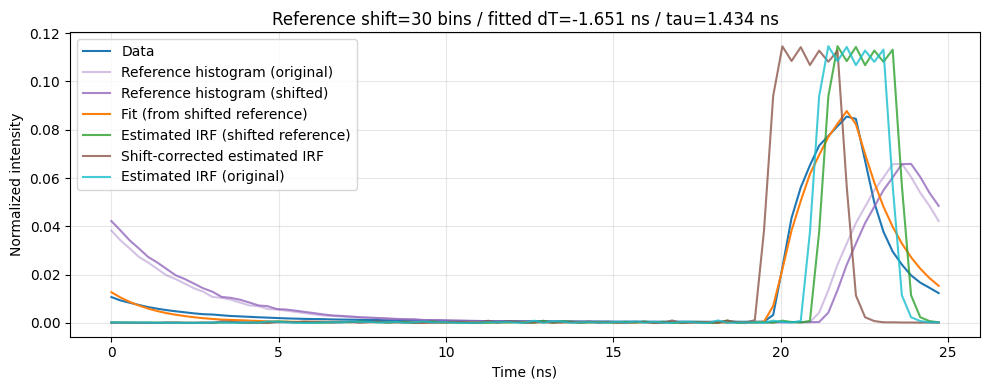

est_irf_shifted_norm_phasor_value: 0.769197-0.576706j
data_norm_phasor_value: 0.656240-0.529742j
ref_hist_shifted_norm_phasor_value: 0.813467-0.039477j
tau_phi and tau_mod from data and shifted IRF: 0.142494 ns 	 nan ns
tau_phi and tau_mod from data and shifted reference: 2.905007 ns 	 1.070257 ns
tau_phi and tau_mod from shifted IRF and reference: 2.692122 ns 	 2.495758 ns


/tmp/ipykernel_1390621/3439651112.py:94: RuntimeWarning: invalid value encountered in sqrt
  tau_mod = np.sqrt(1.0 / (g * g + s * s) - 1.0) / omega


<Figure size 640x480 with 0 Axes>

In [92]:
_, _, data_phasor_delay_ns = Alignment.phasor_delay_from_hist(data_hist_raw, period_ns)
shift = 30


ref_hist_shifted_norm = ref_hist_shifted / ref_hist_shifted.sum()

est_irf_shifted = np.asarray(
    Alignment.IRF_from_data_deconvolution(
        ref_hist_shifted_norm,
        t_ns,
        C_REF,
        tau_ref_ns,
        period_ns,
        iterations=IRF_ITERATIONS,
        regularization=0
    ),
    dtype=float,
)
est_irf_shifted_norm = est_irf_shifted / est_irf_shifted.sum()

fit_result_shifted, fit_cov_shifted = Alignment.perform_fit_data(
    t_ns,
    data_hist_raw,
    est_irf_shifted,
    period_ns,
    fit_type="circular",
    mode=FIT_MODE
)

print(f"dT from fit: {fit_result_shifted['dT'] * dt_ns:.3f} ns")

fitted_hist_shifted = np.asarray(
    Alignment.fit_model_data(
        t_ns,
        fit_result_shifted["C"],
        fit_result_shifted["dT"],
        fit_result_shifted["tau"],
        irf=est_irf_shifted_norm,
        period=period_ns,
    ),
    dtype=float,
)
fitted_hist_shifted_norm = fitted_hist_shifted / fitted_hist_shifted.sum()

dT = fit_result_shifted["dT"]

#est_NEWSHIFT = Alignment.linear_shift(est_irf_ref_norm, ((dT - dT + 1 / 2) % nbin) - nbin / 2, cyclic=True)
est_NEWSHIFT = Alignment.linear_shift(est_irf_shifted, dT, cyclic=True)
est_NEWSHIFT_norm = est_NEWSHIFT / est_NEWSHIFT.sum()

ref_NEWSHIFT = Alignment.linear_shift(ref_hist_shifted_norm, dT, cyclic=True)
ref_NEWSHIFT_norm = ref_NEWSHIFT / ref_NEWSHIFT.sum()

plt.figure(figsize=(10, 4))
plt.plot(t_ns, data_hist_raw_norm, label="Data", color="tab:blue")
plt.plot(t_ns, ref_hist_raw_norm, label="Reference histogram (original)", color="tab:purple", alpha=0.4)
plt.plot(t_ns, ref_hist_shifted_norm, label="Reference histogram (shifted)", color="tab:purple", alpha=0.8)
plt.plot(t_ns, fitted_hist_shifted_norm, label="Fit (from shifted reference)", color="tab:orange")
plt.plot(t_ns, est_irf_shifted_norm, label="Estimated IRF (shifted reference)", color="tab:green", alpha=0.8)
plt.plot(t_ns, est_NEWSHIFT_norm, label="Shift-corrected estimated IRF", color="tab:brown", alpha=0.8)
plt.plot(t_ns, est_irf_ref_norm, label="Estimated IRF (original)", color="tab:cyan", alpha=0.8)
plt.xlabel("Time (ns)")
plt.ylabel("Normalized intensity")
plt.title(
    f"Reference shift={shift} bins / fitted dT={fit_result_shifted['dT'] * dt_ns:.3f} ns / tau={fit_result_shifted['tau']:.3f} ns"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure()
est_irf_shifted_norm_phasor_value = Alignment.phasor_delay_from_hist(est_irf_shifted, period_ns)[0]
data_norm_phasor_value = Alignment.phasor_delay_from_hist(data_hist_raw, period_ns)[0]  
ref_hist_shifted_norm_phasor_value = Alignment.phasor_delay_from_hist(ref_hist_shifted, period_ns)[0]

print(f"est_irf_shifted_norm_phasor_value: {est_irf_shifted_norm_phasor_value:.6f}")
print(f"data_norm_phasor_value: {data_norm_phasor_value:.6f}")
print(f"ref_hist_shifted_norm_phasor_value: {ref_hist_shifted_norm_phasor_value:.6f}")


delta_phasor_value_data_and_ref = ref_hist_shifted_norm_phasor_value / data_norm_phasor_value  # * np.exp(-1j * np.angle(ref_hist_shifted_norm_phasor_value))
delta_phasor_value_data_and_irf = est_irf_shifted_norm_phasor_value / data_norm_phasor_value # * np.exp(-1j * np.angle(est_irf_shifted_norm_phasor_value))
delta_phasor_value_irf_and_ref = ref_hist_shifted_norm_phasor_value / est_irf_shifted_norm_phasor_value # * np.exp(-1j * np.angle(ref_hist_shifted_norm_phasor_value))  



def tau_from_phasor(phasor: np.complex128, period: float) -> tuple[float, float]:
    g = phasor.real
    s = phasor.imag
    omega = 2.0 * np.pi / period
    tau_phi = s / (omega * g)
    tau_mod = np.sqrt(1.0 / (g * g + s * s) - 1.0) / omega
    return tau_phi, tau_mod

tau_phi_data_and_irf, tau_mod_data_and_irf = tau_from_phasor(delta_phasor_value_data_and_irf, period_ns)
tau_phi_data_and_ref, tau_mod_data_and_ref = tau_from_phasor(delta_phasor_value_data_and_ref, period_ns)
tau_phi_irf_and_ref, tau_mod_irf_and_ref = tau_from_phasor(delta_phasor_value_irf_and_ref, period_ns)

print(f"tau_phi and tau_mod from data and shifted IRF: {tau_phi_data_and_irf:.6f} ns \t {tau_mod_data_and_irf:.6f} ns")
print(f"tau_phi and tau_mod from data and shifted reference: {tau_phi_data_and_ref:.6f} ns \t {tau_mod_data_and_ref:.6f} ns")
print(f"tau_phi and tau_mod from shifted IRF and reference: {tau_phi_irf_and_ref:.6f} ns \t {tau_mod_irf_and_ref:.6f} ns")

## Re-estimate the IRF from `ref_NEWSHIFT` and check whether `dT` is near zero


Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
Re-estimated IRF from ref_NEWSHIFT_norm
dT = -0.000 bins = -0.000 ns
tau = 1.434 ns
Is dT about zero (< 0.5 bins)? True


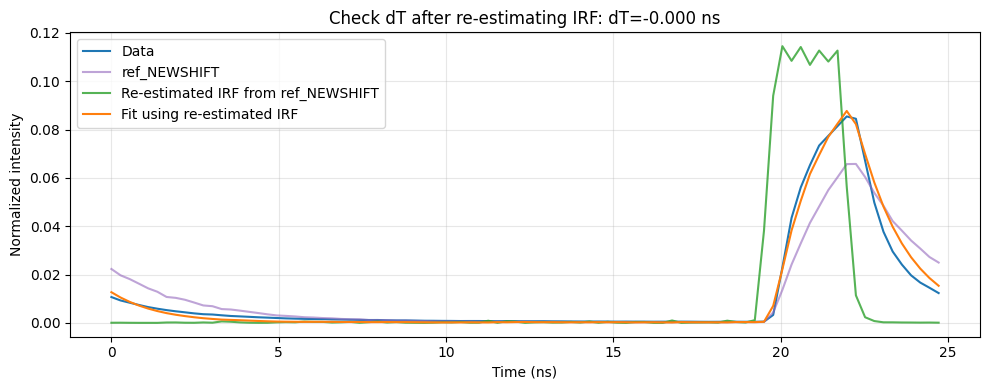

In [93]:
est_irf_newshift = np.asarray(
    Alignment.IRF_from_data_deconvolution(
        ref_NEWSHIFT_norm,
        t_ns,
        C_REF,
        tau_ref_ns,
        period_ns,
        iterations=IRF_ITERATIONS,
        regularization=0,
    ),
    dtype=float,
)
est_irf_newshift_norm = est_irf_newshift / est_irf_newshift.sum()

fit_result_newshift_irf, fit_cov_newshift_irf = Alignment.perform_fit_data(
    t_ns,
    data_hist_raw,
    est_irf_newshift_norm,
    period_ns,
    fit_type="circular",
    mode=FIT_MODE,
)

dT_newshift_irf_bins = fit_result_newshift_irf["dT"]
dT_newshift_irf_ns = dT_newshift_irf_bins * dt_ns
is_dt_about_zero = abs(dT_newshift_irf_bins) < 0.5

print("Re-estimated IRF from ref_NEWSHIFT_norm")
print(f"dT = {dT_newshift_irf_bins:.3f} bins = {dT_newshift_irf_ns:.3f} ns")
print(f"tau = {fit_result_newshift_irf['tau']:.3f} ns")
print(f"Is dT about zero (< 0.5 bins)? {is_dt_about_zero}")

fitted_hist_newshift_irf = np.asarray(
    Alignment.fit_model_data(
        t_ns,
        fit_result_newshift_irf["C"],
        fit_result_newshift_irf["dT"],
        fit_result_newshift_irf["tau"],
        irf=est_irf_newshift_norm,
        period=period_ns,
        mode=FIT_MODE,
    ),
    dtype=float,
)
fitted_hist_newshift_irf_norm = fitted_hist_newshift_irf / fitted_hist_newshift_irf.sum()

plt.figure(figsize=(10, 4))
plt.plot(t_ns, data_hist_raw_norm, label="Data", color="tab:blue")
plt.plot(t_ns, ref_NEWSHIFT_norm, label="ref_NEWSHIFT", color="tab:purple", alpha=0.6)
plt.plot(t_ns, est_irf_newshift_norm, label="Re-estimated IRF from ref_NEWSHIFT", color="tab:green", alpha=0.8)
plt.plot(t_ns, fitted_hist_newshift_irf_norm, label="Fit using re-estimated IRF", color="tab:orange")
plt.xlabel("Time (ns)")
plt.ylabel("Normalized intensity")
plt.title(f"Check dT after re-estimating IRF: dT={dT_newshift_irf_ns:.3f} ns")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
